# Обзор `bybit_BTCUSDT_ohlc_interval_1min.csv`

Минутные свечи **OHLCV** по **BTCUSDT** (биржа Bybit). Ноутбук даёт наглядную обзорную картину: структура файла, описание колонок, базовые метрики качества и распределения.

Подробное текстовое описание полей: см. [`schema.md`](schema.md) в этой же папке `data/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = Path(".")  # ноутбук лежит рядом с CSV
CSV_NAME = "bybit_BTCUSDT_ohlc_interval_1min.csv"
CSV_PATH = DATA_DIR / CSV_NAME

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

assert CSV_PATH.is_file(), f"Не найден файл: {CSV_PATH.resolve()}"

## Описание колонок

| Колонка | Смысл | Единицы / тип |
|---------|--------|----------------|
| `datetime` | Метка времени начала минутной свечи | `YYYY-MM-DD HH:MM:SS` |
| `price_open` | Цена первой сделки в минуте | USDT за BTC |
| `price_high` | Максимум за минуту | USDT |
| `price_low` | Минимум за минуту | USDT |
| `price_close` | Цена последней сделки в минуте | USDT |
| `volume` | Объём торгов базовым активом | BTC |
| `turnover` | Денежный оборот за минуту | USDT |

**Инварианты качества:** `price_low ≤ open, close ≤ price_high`; `volume, turnover ≥ 0`; для одного инструмента не должно быть дубликатов `datetime`.

### Быстрый просмотр (первые 15 строк без полной загрузки)

Далее — полное чтение файла; после него в таблице будут показаны первые и последние строки полного датасета.

In [2]:
peek = pd.read_csv(CSV_PATH, nrows=15, parse_dates=["datetime"])
print(f"Файл: {CSV_PATH.name} (фрагмент)")
display(peek)

Файл: bybit_BTCUSDT_ohlc_interval_1min.csv (фрагмент)


,datetime,price_open,price_high,price_low,price_close,volume,turnover
0,2021-07-06 08:00:00,"34,883.040000","34,892.140000","34,876.270000","34,892.140000",0.000624,21.768537
1,2021-07-06 08:01:00,"34,892.140000","34,892.140000","34,825.220000","34,825.220000",0.000562,19.582348
2,2021-07-06 08:02:00,"34,825.220000","34,825.220000","34,792.900000","34,792.900000",0.000261,9.080947
3,2021-07-06 08:03:00,"34,792.900000","34,841.010000","34,792.900000","34,841.010000",0.000827,28.811510
4,2021-07-06 08:04:00,"34,841.010000","34,841.010000","34,798.810000","34,816.300000",0.000835,29.064349
5,2021-07-06 08:05:00,"34,816.300000","34,816.300000","34,784.730000","34,784.730000",0.000951,33.086834
6,2021-07-06 08:06:00,"34,784.730000","34,799.160000","34,774.880000","34,799.160000",0.000699,24.316285
7,2021-07-06 08:07:00,"34,799.160000","34,807.490000","34,783.900000","34,783.900000",0.000671,23.346696
8,2021-07-06 08:08:00,"34,783.900000","34,802.910000","34,783.900000","34,801.820000",0.000771,26.832628
9,2021-07-06 08:09:00,"34,801.820000","34,835.840000","34,801.820000","34,835.840000",0.001172,40.821418


### Полная загрузка CSV

In [3]:
# Полная загрузка (~1.6M строк, обычно укладывается в RAM на типичной машине)
df = pd.read_csv(CSV_PATH, parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print("Первые 8 строк:")
display(df.head(8))
print("Последние 8 строк:")
display(df.tail(8))

Первые 8 строк:


,datetime,price_open,price_high,price_low,price_close,volume,turnover
0,2021-07-06 08:00:00,"34,883.040000","34,892.140000","34,876.270000","34,892.140000",0.000624,21.768537
1,2021-07-06 08:01:00,"34,892.140000","34,892.140000","34,825.220000","34,825.220000",0.000562,19.582348
2,2021-07-06 08:02:00,"34,825.220000","34,825.220000","34,792.900000","34,792.900000",0.000261,9.080947
3,2021-07-06 08:03:00,"34,792.900000","34,841.010000","34,792.900000","34,841.010000",0.000827,28.811510
4,2021-07-06 08:04:00,"34,841.010000","34,841.010000","34,798.810000","34,816.300000",0.000835,29.064349
5,2021-07-06 08:05:00,"34,816.300000","34,816.300000","34,784.730000","34,784.730000",0.000951,33.086834
6,2021-07-06 08:06:00,"34,784.730000","34,799.160000","34,774.880000","34,799.160000",0.000699,24.316285
7,2021-07-06 08:07:00,"34,799.160000","34,807.490000","34,783.900000","34,783.900000",0.000671,23.346696


Последние 8 строк:


,datetime,price_open,price_high,price_low,price_close,volume,turnover
1601937,2024-07-22 18:57:00,"67,427.260000","67,479.260000","67,424.720000","67,475.110000",9.793021,"660,535.034963"
1601938,2024-07-22 18:58:00,"67,475.110000","67,482.850000","67,428.980000","67,451.700000",10.493652,"707,851.731221"
1601939,2024-07-22 18:59:00,"67,451.700000","67,454.030000","67,432.740000","67,450.410000",7.136744,"481,310.407329"
1601940,2024-07-22 19:00:00,"67,450.410000","67,456.380000","67,392.460000","67,398.000000",19.286576,"1,300,206.812207"
1601941,2024-07-22 19:01:00,"67,398.000000","67,455.330000","67,368.910000","67,455.330000",14.806998,"997,890.869879"
1601942,2024-07-22 19:02:00,"67,455.330000","67,459.100000","67,391.330000","67,402.420000",16.181026,"1,091,081.610122"
1601943,2024-07-22 19:03:00,"67,402.420000","67,502.390000","67,395.540000","67,501.040000",20.080800,"1,354,178.178902"
1601944,2024-07-22 19:04:00,67.000000,nan,nan,nan,nan,nan


### Размер, типы, память

In [4]:
summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "null_count": df.isna().sum(),
    }
)
display(summary)

n_dup = int(df["datetime"].duplicated().sum())
print(f"Число строк: {len(df):,}")
print(f"Число колонок: {df.shape[1]}")
print(f"Память DataFrame (прибл.): {df.memory_usage(deep=True).sum() / 1e6:,.1f} MB")
print(f"Дубликаты datetime: {n_dup:,}")
print(
    f"Интервал дат: {df['datetime'].min()} — {df['datetime'].max()}"
)

,dtype,non_null,null_count
datetime,datetime64[ns],1601945,0
price_open,float64,1601945,0
price_high,float64,1601944,1
price_low,float64,1601944,1
price_close,float64,1601944,1
volume,float64,1601944,1
turnover,float64,1601944,1


Число строк: 1,601,945
Число колонок: 7
Память DataFrame (прибл.): 89.7 MB
Дубликаты datetime: 0
Интервал дат: 2021-07-06 08:00:00 — 2024-07-22 19:04:00


### Числовые метрики (describe)

In [5]:
num_cols = [
    "price_open",
    "price_high",
    "price_low",
    "price_close",
    "volume",
    "turnover",
]
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

,count,mean,std,min,1%,5%,50%,95%,99%,max
price_open,"1,601,945.000000","37,566.664183","15,553.905080",67.000000,"16,555.994400","17,200.694000","34,303.980000","67,027.976000","70,526.628800","73,780.920000"
price_high,"1,601,944.000000","37,581.384134","15,561.152958","15,552.580000","16,560.208600","17,203.776000","34,314.820000","67,059.087000","70,555.570000","73,800.000000"
price_low,"1,601,944.000000","37,551.932004","15,546.452909","15,484.340000","16,551.820000","17,197.574500","34,291.495000","66,997.778000","70,497.990000","73,686.280000"
price_close,"1,601,944.000000","37,566.707902","15,553.899535","15,513.190000","16,556.000000","17,200.711500","34,303.990000","67,027.997000","70,526.631100","73,780.920000"
volume,"1,601,944.000000",4.906220,12.113996,0.000000,0.000484,0.008268,1.730262,18.584328,44.744873,"1,335.599829"
turnover,"1,601,944.000000","196,334.144656","524,183.353094",0.000000,17.409549,328.999929,"52,893.813499","828,265.051501","1,998,543.381474","65,840,655.332501"


### Ряд по времени: число свечей по годам / месяцам

In [6]:
df["year"] = df["datetime"].dt.year
df["ym"] = df["datetime"].dt.to_period("M")

by_year = df.groupby("year").size().rename("rows").to_frame()
display(by_year)

by_month = df.groupby("ym").size().rename("rows").to_frame()
by_month.index = by_month.index.astype(str)
display(by_month.tail(24))

,rows
year,
2021,257280
2022,525600
2023,525600
2024,293465


,rows
ym,
2022-08,44640
2022-09,43200
2022-10,44640
2022-11,43200
2022-12,44640
2023-01,44640
2023-02,40320
2023-03,44640
2023-04,43200


### Проверки согласованности OHLC (счётчики нарушений)

In [7]:
viol_low = (df["price_low"] > df[["price_open", "price_close"]].min(axis=1)).sum()
viol_high = (df["price_high"] < df[["price_open", "price_close"]].max(axis=1)).sum()
viol_nonneg = ((df["volume"] < 0) | (df["turnover"] < 0)).sum()

checks = pd.DataFrame(
    {
        "metric": [
            "rows где low > min(open,close)",
            "rows где high < max(open,close)",
            "rows с volume<0 или turnover<0",
        ],
        "count": [viol_low, viol_high, viol_nonneg],
    }
)
display(checks)

,metric,count
0,"rows где low > min(open,close)",0
1,"rows где high < max(open,close)",0
2,rows с volume<0 или turnover<0,0


### Визуализация: закрытие и объём (резкая выборка по дням для скорости)

Для быстрого графика можно ресемплировать дневной close; полный минутный ряд на графике из миллионов точек не нужен.

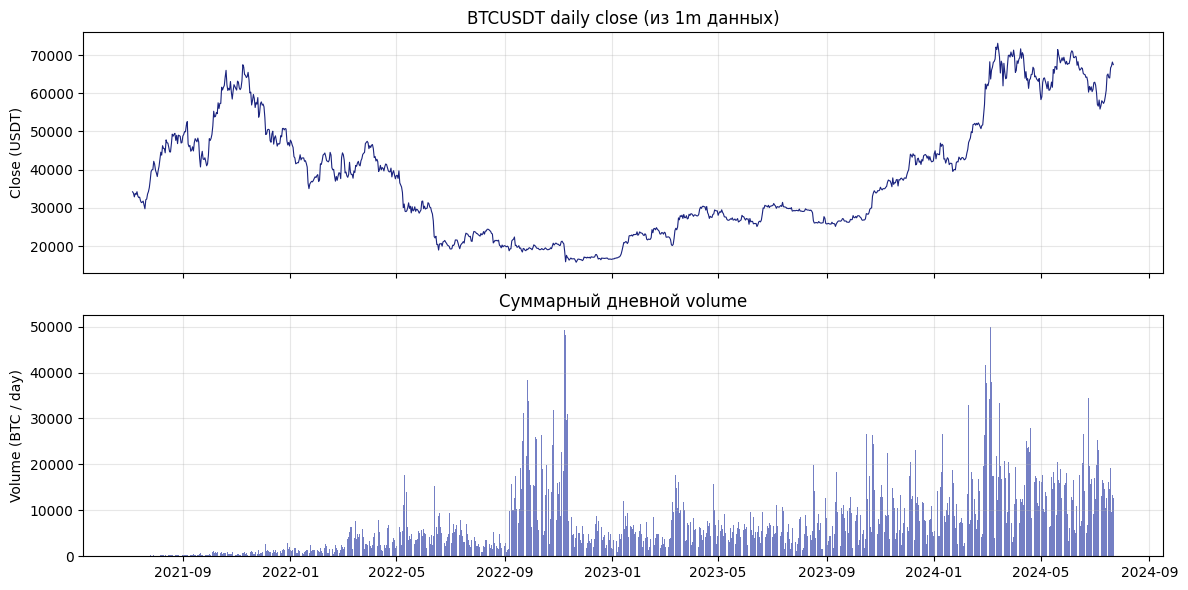

In [8]:
import matplotlib.pyplot as plt

daily = df.set_index("datetime").sort_index()
dc = daily["price_close"].resample("1D").last().dropna()
dv = daily["volume"].resample("1D").sum().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(dc.index, dc.values, color="#1a237e", linewidth=0.8)
axes[0].set_ylabel("Close (USDT)")
axes[0].set_title("BTCUSDT daily close (из 1m данных)")
axes[0].grid(True, alpha=0.3)

axes[1].bar(dv.index, dv.values, width=0.8, color="#3949ab", alpha=0.7)
axes[1].set_ylabel("Volume (BTC / day)")
axes[1].set_title("Суммарный дневной volume")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()